In [2]:
from pathlib import Path

from scipy.constants import point


def find_project_root(start: Path) -> Path:
   for candidate in [start, *start.parents]:
       if (candidate / "pyproject.toml").exists():
           return candidate
   raise FileNotFoundError("Could not find project root containing pyproject.toml.")
project_root = find_project_root(Path.cwd()).resolve()

In [9]:
import pandas as pd
from sklearn.datasets import make_blobs

RANDOM_STATE = 42

data_path = project_root / "data" / "generated" / "week-04-2d-points.csv"
data_path.parent.mkdir(parents=True, exist_ok=True)

# creates 300 labeled 2D points
X, y = make_blobs(
    n_samples=300,
    centers=[(-2.0, -2.0), (2.0, 2.0)], # Two class centers: one lower-left, one upper-right.
    cluster_std=0.9,
    random_state=RANDOM_STATE,
)

points = pd.DataFrame(
    {
        "x_position": X[:, 0],
        "y_position": X[:, 1],
        "class_label": y,
    }
)

points.to_csv(data_path, index=False)
print(points.shape)
points.head()

(300, 3)


,x_position,y_position,class_label
0,-3.072173,-1.409102,0
1,-2.489944,-1.900170,0
2,2.108266,2.462995,1
3,-2.883358,-1.584107,0
4,-1.947612,-3.028673,0


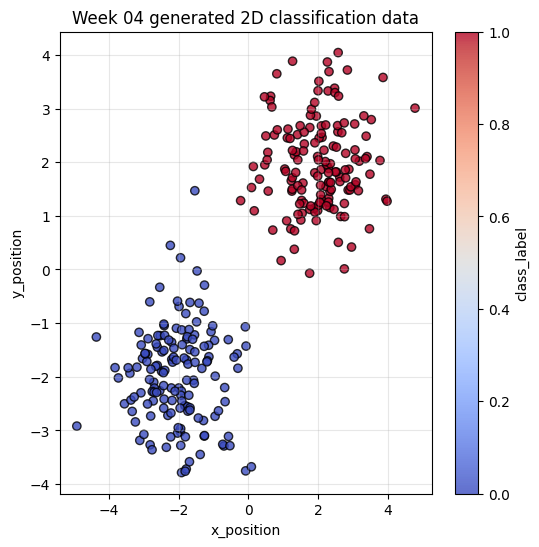

C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-04-classification\data_plot.png


In [5]:
import matplotlib.pyplot as plt

artifact_path = project_root / "artifacts" / "week-04-classification" / "data_plot.png"
artifact_path.parent.mkdir(parents=True, exist_ok=True)

figure, axis = plt.subplots(figsize=(6, 6))

scatter = axis.scatter(
   points["x_position"],
   points["y_position"],
   c=points["class_label"],
   cmap="coolwarm",
   edgecolors="black",
   alpha=0.8,
)

axis.set_title("Week 04 generated 2D classification data")
axis.set_xlabel("x_position")
axis.set_ylabel("y_position")
axis.grid(True, alpha=0.3)

figure.colorbar(scatter, ax=axis, label="class_label")
figure.savefig(artifact_path, dpi=150, bbox_inches="tight")

plt.show()

print(artifact_path)

In [6]:
import numpy as np
from numpy.typing import NDArray

from sklearn.model_selection import train_test_split

FloatArray = NDArray[np.float64]
IntArray = NDArray[np.int64]

features: FloatArray = points[["x_position", "y_position"]].to_numpy(dtype=np.float64)
labels: IntArray = points["class_label"].to_numpy(dtype=np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("Train class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))

X_train: (240, 2)
X_test: (60, 2)
y_train: (240,)
y_test: (60,)
Train class counts: [120 120]
Test class counts: [30 30]


In [10]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print("X_train_tensor:", X_train_tensor.shape, X_train_tensor.dtype)
print("y_train_tensor:", y_train_tensor.shape, y_train_tensor.dtype)
print("X_test_tensor:", X_test_tensor.shape, X_test_tensor.dtype)
print("y_test_tensor:", y_test_tensor.shape, y_test_tensor.dtype)

X_train_tensor: torch.Size([240, 2]) torch.float32
y_train_tensor: torch.Size([240, 1]) torch.float32
X_test_tensor: torch.Size([60, 2]) torch.float32
y_test_tensor: torch.Size([60, 1]) torch.float32
